In [ ]:
# ================================================================
#  NASA C-MAPSS TURBOFAN — TAM EĞİTİM NOTEBOOK
#  Google Colab | GPU T4 | PyTorch + Sklearn
#  Veri: 6. Turbofan Engine Degradation Simulation Data Set
# ================================================================
#
#  VERİ SETİ YAPISI (gerçek analiz sonuçları):
#  ┌────────┬──────────┬───────┬───────────┬────────────────────┐
#  │ Subset │ Train    │ Test  │ Motor     │ Op. Koşul          │
#  ├────────┼──────────┼───────┼───────────┼────────────────────┤
#  │ FD001  │ 20,631   │ 13,096│ 100       │ 1 koşul, 1 arıza   │
#  │ FD002  │ 53,759   │ 33,991│ 260       │ 6 koşul, 1 arıza   │
#  │ FD003  │ 24,720   │ 16,596│ 100       │ 1 koşul, 2 arıza   │
#  │ FD004  │ 61,249   │ 41,214│ 249       │ 6 koşul, 2 arıza   │
#  └────────┴──────────┴───────┴───────────┴────────────────────┘
#
#  KULLANIM:
#   1. Runtime → Change Runtime Type → GPU (T4)
#   2. zip'i Drive'a yükle
#   3. Hücreleri sırayla çalıştır
# ================================================================

In [2]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 1 — Kurulum & GPU Kontrolü               ║
# ╚══════════════════════════════════════════════════╝

!pip install shap -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import time, warnings, os, zipfile, shutil
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{'='*50}")
print(f"  Cihaz : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU   : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("  ⚠️  GPU YOK! Runtime → Change Runtime Type → GPU → T4")
print(f"{'='*50}")

  Cihaz : cuda
  GPU   : Tesla T4
  VRAM  : 15.6 GB


In [3]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 2 — Veriyi Drive'dan Yükle               ║
# ╚══════════════════════════════════════════════════╝

from google.colab import drive
drive.mount('/content/drive')

# ── Zip yolunu kendi Drive konumuna göre düzenle ──
OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
DATA_DIR  = '/content/CMAPSSData'

# Dış zip'i aç
outer_extract = '/content/outer_zip'
with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
    z.extractall(outer_extract)

# İç zip'i bul ve aç
inner_zip = None
for root, dirs, files in os.walk(outer_extract):
    for f in files:
        if f.endswith('.zip'):
            inner_zip = os.path.join(root, f)
            break

print(f"İç zip bulundu: {inner_zip}")
with zipfile.ZipFile(inner_zip, 'r') as z:
    z.extractall(DATA_DIR)

print(f"\nDosyalar ({DATA_DIR}):")
for f in sorted(os.listdir(DATA_DIR)):
    size = os.path.getsize(os.path.join(DATA_DIR, f))
    print(f"  {f:<35} {size/1024:.0f} KB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
İç zip bulundu: /content/outer_zip/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip

Dosyalar (/content/CMAPSSData):
  Damage Propagation Modeling.pdf     424 KB
  RUL_FD001.txt                       0 KB
  RUL_FD002.txt                       1 KB
  RUL_FD003.txt                       0 KB
  RUL_FD004.txt                       1 KB
  readme.txt                          2 KB
  test_FD001.txt                      2177 KB
  test_FD002.txt                      5600 KB
  test_FD003.txt                      2760 KB
  test_FD004.txt                      6795 KB
  train_FD001.txt                     3433 KB
  train_FD002.txt                     8870 KB
  train_FD003.txt                     4115 KB
  train_FD004.txt                     10108 KB


In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 3 — Veri Seti Analizi                    ║
# ╚══════════════════════════════════════════════════╝
# Bu hücre veriyi tanımanı sağlar — çalıştır, çıktıyı oku

COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

# Her subset için sabit sensörler (gerçek veri analizinden)
CONSTANT_SENSORS = {
    'FD001': ['s1','s5','s6','s10','s16','s18','s19'],
    'FD002': ['s16'],
    'FD003': ['s1','s5','s10','s16','s18','s19'],
    'FD004': ['s16'],
}

# Her subset için kullanılacak özellikler (otomatik hesaplanır)
FEAT_COLS_MAP = {}

print(f"\n{'Subset':<8} {'Train':>8} {'Test':>7} {'Motor':>7} {'Kullanışlı Sensör':>18} {'RUL Ort':>8}")
print("─"*60)

for subset in ['FD001','FD002','FD003','FD004']:
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')

    sensor_cols = [f's{i}' for i in range(1,22)]
    stds        = train[sensor_cols].std()
    useful      = stds[stds > 0.01].index.tolist()

    # Operasyon ayarlarını da ekle (çok koşullu subsetlerde önemli)
    op_cols = ['op1','op2','op3'] if train['op3'].nunique() > 1 else ['op3']
    feat_cols = op_cols + useful
    FEAT_COLS_MAP[subset] = feat_cols

    print(f"{subset:<8} {len(train):>8,} {len(test):>7,} "
          f"{train['unit'].nunique():>7} {len(useful):>18} {rul['rul'].mean():>8.1f}")

print("\nKullanılacak özellik sayıları:")
for s, f in FEAT_COLS_MAP.items():
    print(f"  {s}: {len(f)} özellik → {f}")



Subset      Train    Test   Motor  Kullanışlı Sensör  RUL Ort
────────────────────────────────────────────────────────────
FD001      20,631  13,096     100                 14     75.5
FD002      53,759  33,991     260                 20     81.2
FD003      24,720  16,596     100                 15     75.3
FD004      61,249  41,214     249                 20     86.6

Kullanılacak özellik sayıları:
  FD001: 15 özellik → ['op3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
  FD002: 23 özellik → ['op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's17', 's18', 's19', 's20', 's21']
  FD003: 16 özellik → ['op3', 's2', 's3', 's4', 's6', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
  FD004: 23 özellik → ['op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's17', 's18', 's19', 's20', 's2

In [5]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 4 — Ön İşleme Fonksiyonları              ║
# ╚══════════════════════════════════════════════════╝

MAX_RUL = 125    # Piece-Wise Linear RUL cap (literatür standardı)
SEQ_LEN = 30     # Kayan pencere uzunluğu

def load_subset(subset):
    """Ham txt dosyalarını yükle"""
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')
    return train, test, rul


def add_rul_train(df):
    """
    Train verisi için RUL hesapla.
    Yöntem: max_cycle - current_cycle, cap=MAX_RUL
    Piece-Wise Linear: motor yeniyken RUL=MAX_RUL, kritik noktada azalır
    """
    df = df.copy()
    max_c = df.groupby('unit')['cycle'].max()
    df['max_cycle'] = df['unit'].map(max_c)
    df['rul'] = (df['max_cycle'] - df['cycle']).clip(0, MAX_RUL)
    df.drop(columns=['max_cycle'], inplace=True)
    return df


def add_rul_test(test_df, rul_df):
    """
    Test verisi için RUL hesapla.
    Her motorun son kaydına rul_df'den gerçek RUL atanır,
    önceki döngüler geriye sayılarak hesaplanır.
    """
    test_df = test_df.copy()
    last_cycles = test_df.groupby('unit')['cycle'].max().reset_index()
    last_cycles.columns = ['unit', 'last_cycle']
    last_cycles['final_rul'] = rul_df['rul'].values

    test_df = test_df.merge(last_cycles, on='unit', how='left')
    test_df['rul'] = (test_df['final_rul'] +
                      test_df['last_cycle'] -
                      test_df['cycle']).clip(0, MAX_RUL)
    test_df.drop(columns=['last_cycle','final_rul'], inplace=True)
    return test_df


def normalize(train_df, test_df, feat_cols):
    """
    MinMax normalizasyonu.
    ÖNEMLİ: Scaler sadece train ile fit edilir!
    """
    train_df = train_df.copy()
    test_df  = test_df.copy()
    scaler   = MinMaxScaler()
    train_df[feat_cols] = scaler.fit_transform(train_df[feat_cols])
    test_df[feat_cols]  = scaler.transform(test_df[feat_cols])
    return train_df, test_df, scaler


def make_sequences(df, feat_cols, seq_len=SEQ_LEN):
    """
    Sliding window → LSTM/CNN için 3D dizi
    X: (N, seq_len, n_features)
    y: (N,) — pencerenin son döngüsünün RUL değeri
    """
    X_list, y_list = [], []
    for _, grp in df.groupby('unit'):
        grp  = grp.sort_values('cycle')
        vals = grp[feat_cols].values
        ruls = grp['rul'].values
        for i in range(len(vals) - seq_len + 1):
            X_list.append(vals[i : i + seq_len])
            y_list.append(ruls[i + seq_len - 1])
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32))


def prepare_subset(subset):
    """Tam pipeline: yükle → RUL → normalize → sequence"""
    print(f"\n[{subset}] Hazırlanıyor...", end='')
    feat_cols = FEAT_COLS_MAP[subset]

    train_raw, test_raw, rul_raw = load_subset(subset)
    train_df = add_rul_train(train_raw)
    test_df  = add_rul_test(test_raw, rul_raw)
    train_df, test_df, scaler = normalize(train_df, test_df, feat_cols)

    # Sequence (DL için)
    X_tr_seq, y_tr_seq = make_sequences(train_df, feat_cols)
    X_te_seq, y_te_seq = make_sequences(test_df,  feat_cols)

    # Flat (ML için)
    X_tr_flat = train_df[feat_cols].values
    y_tr_flat = train_df['rul'].values
    X_te_flat = test_df[feat_cols].values
    y_te_flat = test_df['rul'].values

    print(f" ✓  Seq: {X_tr_seq.shape} / Flat: {X_tr_flat.shape}")
    return {
        'subset':    subset,
        'feat_cols': feat_cols,
        'n_feat':    len(feat_cols),
        'scaler':    scaler,
        'X_tr_seq':  X_tr_seq,  'y_tr_seq': y_tr_seq,
        'X_te_seq':  X_te_seq,  'y_te_seq': y_te_seq,
        'X_tr_flat': X_tr_flat, 'y_tr_flat': y_tr_flat,
        'X_te_flat': X_te_flat, 'y_te_flat': y_te_flat,
        'train_df':  train_df,  'test_df':   test_df,
    }

# Seçilen subset — değiştirerek FD002/FD003/FD004 de deneyebilirsin
SUBSET = 'FD001'
data   = prepare_subset(SUBSET)

print(f"\n{'─'*50}")
print(f"  Subset      : {SUBSET}")
print(f"  Özellik sayısı: {data['n_feat']}")
print(f"  DL Train    : {data['X_tr_seq'].shape}")
print(f"  DL Test     : {data['X_te_seq'].shape}")
print(f"  ML Train    : {data['X_tr_flat'].shape}")
print(f"  RUL Aralığı : {data['y_tr_seq'].min():.0f} – {data['y_tr_seq'].max():.0f}")
print(f"{'─'*50}")



[FD001] Hazırlanıyor... ✓  Seq: (17731, 30, 15) / Flat: (20631, 15)

──────────────────────────────────────────────────
  Subset      : FD001
  Özellik sayısı: 15
  DL Train    : (17731, 30, 15)
  DL Test     : (10196, 30, 15)
  ML Train    : (20631, 15)
  RUL Aralığı : 0 – 125
──────────────────────────────────────────────────


In [7]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 5 — Metrik Fonksiyonları                 ║
# ╚══════════════════════════════════════════════════╝

def nasa_score(y_true, y_pred):
    """
    NASA resmi RUL değerlendirme metriği.
    d < 0 → erken tahmin (hafif ceza): e^(-d/13) - 1
    d > 0 → geç tahmin  (ağır ceza) : e^(d/10)  - 1
    Toplam düşük olması beklenir.
    """
    d = np.array(y_pred, dtype=float) - np.array(y_true, dtype=float)
    s = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(s.sum())

def metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

def print_metrics(name, m, elapsed=None):
    t = f"  {elapsed:.1f}s" if elapsed else ""
    print(f"  {name:<22}  RMSE={m['RMSE']:7.3f}  MAE={m['MAE']:6.3f}"
          f"  R²={m['R2']:7.4f}  Score={m['Score']:10.1f}{t}")


In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 6 — Geleneksel ML Modelleri              ║
# ╚══════════════════════════════════════════════════╝

print(f"\n{'='*65}")
print(f"  GELENEKSEL ML MODELLERİ — {SUBSET}")
print(f"{'='*65}")

X_tr = data['X_tr_flat']
y_tr = data['y_tr_flat']
X_te = data['X_te_flat']
y_te = data['y_te_flat']

ml_models = {
    'Ridge Regression':  Ridge(alpha=1.0),
    'KNN (k=5)':         KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'Decision Tree':     DecisionTreeRegressor(max_depth=10, min_samples_leaf=5,
                                               random_state=SEED),
    'SVR (RBF)':         SVR(kernel='rbf', C=10, gamma='scale', epsilon=0.1),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=None,
                                               n_jobs=-1, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                    max_depth=4, random_state=SEED),
}

ml_results = {}
ml_preds   = {}

for name, mdl in ml_models.items():
    t0 = time.time()

    # SVR büyük veride yavaş → max 8000 örnek
    if 'SVR' in name and len(X_tr) > 8000:
        idx = np.random.choice(len(X_tr), 8000, replace=False)
        mdl.fit(X_tr[idx], y_tr[idx])
    else:
        mdl.fit(X_tr, y_tr)

    preds = mdl.predict(X_te)
    elapsed = time.time() - t0

    m = metrics(y_te, preds)
    m['Time']  = elapsed
    m['Type']  = 'ML'
    ml_results[name] = m
    ml_preds[name]   = preds
    print_metrics(name, m, elapsed)



  GELENEKSEL ML MODELLERİ — FD001
  Ridge Regression        RMSE= 20.787  MAE=16.695  R²= 0.4319  Score=  128981.5  0.0s
  KNN (k=5)               RMSE= 19.143  MAE=13.273  R²= 0.5182  Score=  262675.8  4.4s
  Decision Tree           RMSE= 18.769  MAE=13.089  R²= 0.5369  Score=  283343.1  0.3s
  SVR (RBF)               RMSE= 17.437  MAE=10.829  R²= 0.6003  Score=  328951.1  8.2s
  Random Forest           RMSE= 17.416  MAE=12.673  R²= 0.6012  Score=  177947.7  53.6s
  Gradient Boosting       RMSE= 17.057  MAE=12.061  R²= 0.6175  Score=  200167.4  20.6s


In [10]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 7 — Derin Öğrenme Mimarileri             ║
# ╚══════════════════════════════════════════════════╝

N_FEAT  = data['n_feat']
SEQ_LEN = 30   # Hücre 4 ile aynı olmalı

class LSTMModel(nn.Module):
    """
    Vanilla LSTM
    ─ 2 katmanlı, dropout ile overfite karşı koruma
    ─ Son zaman adımının çıktısı FC katmana verilir
    """
    def __init__(self, n_feat=N_FEAT, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1]).squeeze()


class BiLSTMModel(nn.Module):
    """
    Çift Yönlü LSTM
    ─ İleri + geri iki LSTM birleşimi → 2×hidden boyut
    ─ Vanilla LSTM'den genellikle %20-30 daha iyi RMSE
    """
    def __init__(self, n_feat=N_FEAT, hidden=128, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers,
                            batch_first=True, dropout=dropout,
                            bidirectional=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1]).squeeze()


class CNNLSTMModel(nn.Module):
    """
    CNN + LSTM Hibrit
    ─ 1D Conv: yerel sensör örüntülerini çıkarır (kısa vadeli)
    ─ LSTM   : uzun vadeli temporal bağımlılık
    ─ Hız/doğruluk dengesi en iyi mimari
    """
    def __init__(self, n_feat=N_FEAT, hidden=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(n_feat, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
        )
        self.lstm = nn.LSTM(128, hidden, num_layers=1, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        # (batch, seq, feat) → (batch, feat, seq) → Conv1d → geri çevir
        x = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1]).squeeze()


class TransformerModel(nn.Module):
    """
    Transformer Encoder
    ─ Multi-Head Self-Attention: tüm döngülere aynı anda bakar
    ─ Pozisyonel kodlama: sıra bilgisini korur
    ─ Büyük veride (FD002, FD004) en güçlü model
    """
    def __init__(self, n_feat=N_FEAT, d_model=128, nhead=4, layers=3, dropout=0.1):
        super().__init__()
        self.proj    = nn.Linear(n_feat, d_model)
        self.pos_enc = nn.Parameter(torch.randn(1, SEQ_LEN, d_model) * 0.01)
        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=dropout,
            batch_first=True, norm_first=True   # Pre-LN: daha stabil eğitim
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.proj(x) + self.pos_enc
        x = self.transformer(x)
        return self.fc(x[:, -1]).squeeze()

In [19]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 8 — DL Eğitim Döngüsü                   ║
# ╚══════════════════════════════════════════════════╝

def train_dl_model(model, data_dict, epochs=50, lr=1e-3, batch=256, name=""):
    """
    Evrensel DL eğitim fonksiyonu.
    ─ Optimizer: Adam + weight decay
    ─ Scheduler: CosineAnnealingLR (lr yavaşça sıfıra iner)
    ─ Gradient Clipping: patlayan gradyanları önler
    """
    model = model.to(DEVICE)

    X_tr = torch.tensor(data_dict['X_tr_seq']).to(DEVICE)
    y_tr = torch.tensor(data_dict['y_tr_seq']).to(DEVICE)
    X_te = torch.tensor(data_dict['X_te_seq'])
    y_te_np = data_dict['y_te_seq']

    tr_loader = DataLoader(
        TensorDataset(X_tr, y_tr),
        batch_size=batch, shuffle=True
    )

    # Add DataLoader for validation set to handle large test data
    te_loader = DataLoader(
        TensorDataset(X_te, torch.tensor(y_te_np)),
        batch_size=batch, shuffle=False
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()

    history = {'epoch': [], 'train_loss': [], 'val_rmse': [], 'val_r2': []}
    t0 = time.time()

    for ep in range(1, epochs + 1):
        # ── Train ──────────────────────────────────────
        model.train()
        ep_losses = []
        for xb, yb in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep_losses.append(loss.item())
        scheduler.step()

        # ── Validate ───────────────────────────────────
        if ep % 5 == 0 or ep == 1:
            model.eval()
            val_preds_list = []
            with torch.no_grad():
                for xb_test, _ in te_loader:
                    xb_test = xb_test.to(DEVICE)
                    val_preds_list.append(model(xb_test).cpu().numpy())
            val_preds = np.concatenate(val_preds_list)

            val_rmse = float(np.sqrt(mean_squared_error(y_te_np, val_preds)))
            val_r2   = float(r2_score(y_te_np, val_preds))

            history['epoch'].append(ep)
            history['train_loss'].append(float(np.mean(ep_losses)))
            history['val_rmse'].append(val_rmse)
            history['val_r2'].append(val_r2)

            print(f"  [{name}] Ep {ep:3d}/{epochs}  "
                  f"Loss={np.mean(ep_losses):.4f}  "
                  f"RMSE={val_rmse:.3f}  R²={val_r2:.4f}")

    elapsed = time.time() - t0

    # ── Final metrikler ─────────────────────────────
    model.eval()
    final_preds_list = []
    with torch.no_grad():
        for xb_test, _ in te_loader:
            xb_test = xb_test.to(DEVICE)
            final_preds_list.append(model(xb_test).cpu().numpy())
    final_preds = np.concatenate(final_preds_list)

    m = metrics(y_te_np, final_preds)
    m['Time']    = elapsed
    m['Type']    = 'DL'
    m['history'] = history

    return m, final_preds

In [12]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — Tüm DL Modellerini Eğit             ║
# ╚══════════════════════════════════════════════════╝

print(f"\n{'='*65}")
print(f"  DERİN ÖĞRENME MODELLERİ — {SUBSET}  (50 Epoch, GPU)")
print(f"{'='*65}")

dl_configs = [
    ('LSTM',        LSTMModel(N_FEAT)),
    ('Bi-LSTM',     BiLSTMModel(N_FEAT)),
    ('CNN-LSTM',    CNNLSTMModel(N_FEAT)),
    ('Transformer', TransformerModel(N_FEAT)),
]

dl_results = {}
dl_preds   = {}

for name, model in dl_configs:
    print(f"\n{'─'*55}")
    print(f"  → {name}  |  "
          f"Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"{'─'*55}")

    m, preds = train_dl_model(model, data, epochs=50,
                               lr=1e-3, batch=256, name=name)
    dl_results[name] = m
    dl_preds[name]   = preds

    print(f"\n  ✓ {name} Tamamlandı:")
    print_metrics(name, m, m['Time'])

print(f"\n{'='*65}")
print("  Tüm DL modelleri tamamlandı!")
print(f"{'='*65}")



  DERİN ÖĞRENME MODELLERİ — FD001  (50 Epoch, GPU)

───────────────────────────────────────────────────────
  → LSTM  |  Params: 214,657
───────────────────────────────────────────────────────
  [LSTM] Ep   1/50  Loss=6787.2440  RMSE=84.444  R²=-7.0696
  [LSTM] Ep   5/50  Loss=413.7460  RMSE=18.608  R²=0.6082
  [LSTM] Ep  10/50  Loss=289.6638  RMSE=18.299  R²=0.6210
  [LSTM] Ep  15/50  Loss=251.6759  RMSE=14.929  R²=0.7478
  [LSTM] Ep  20/50  Loss=239.2149  RMSE=16.525  R²=0.6910
  [LSTM] Ep  25/50  Loss=212.7086  RMSE=13.834  R²=0.7834
  [LSTM] Ep  30/50  Loss=198.4496  RMSE=15.184  R²=0.7391
  [LSTM] Ep  35/50  Loss=190.7033  RMSE=13.281  R²=0.8004
  [LSTM] Ep  40/50  Loss=188.2451  RMSE=13.536  R²=0.7927
  [LSTM] Ep  45/50  Loss=186.1275  RMSE=13.533  R²=0.7928
  [LSTM] Ep  50/50  Loss=182.4632  RMSE=13.489  R²=0.7941

  ✓ LSTM Tamamlandı:
  LSTM                    RMSE= 13.489  MAE= 9.707  R²= 0.7941  Score=   32451.5  32.0s

───────────────────────────────────────────────────────

In [13]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 10 — Tam Karşılaştırma Tablosu          ║
# ╚══════════════════════════════════════════════════╝

all_results = {**ml_results, **dl_results}
sorted_res  = sorted(all_results.items(), key=lambda x: x[1]['RMSE'])

print(f"\n{'='*75}")
print(f"  TAM KARŞILAŞTIRMA — {SUBSET}")
print(f"{'='*75}")
print(f"  {'#':<3} {'Model':<22} {'Tip':<4} {'RMSE':>7} {'MAE':>7} "
      f"{'R²':>8} {'NASA Score':>11} {'Süre':>7}")
print(f"  {'─'*70}")

for i, (name, r) in enumerate(sorted_res):
    marker = " ← EN İYİ" if i == 0 else ""
    print(f"  {i+1:<3} {name:<22} {r['Type']:<4} {r['RMSE']:>7.3f} "
          f"{r['MAE']:>7.3f} {r['R2']:>8.4f} {r['Score']:>11.1f} "
          f"{r['Time']:>6.1f}s{marker}")

best_name  = sorted_res[0][0]
best_rmse  = sorted_res[0][1]['RMSE']
best_r2    = sorted_res[0][1]['R2']
best_score = sorted_res[0][1]['Score']

print(f"\n  🏆 En iyi model : {best_name}")
print(f"     RMSE         : {best_rmse:.3f}")
print(f"     R²           : {best_r2:.4f}")
print(f"     NASA Score   : {best_score:.1f}")


  TAM KARŞILAŞTIRMA — FD001
  #   Model                  Tip     RMSE     MAE       R²  NASA Score    Süre
  ──────────────────────────────────────────────────────────────────────
  1   Bi-LSTM                DL    13.430   9.741   0.7959     30901.6   60.4s ← EN İYİ
  2   LSTM                   DL    13.489   9.707   0.7941     32451.5   32.0s
  3   Transformer            DL    14.093   8.728   0.7752     49288.7   69.7s
  4   Gradient Boosting      ML    17.057  12.061   0.6175    200167.4   20.6s
  5   Random Forest          ML    17.416  12.673   0.6012    177947.7   53.6s
  6   SVR (RBF)              ML    17.437  10.829   0.6003    328951.1    8.2s
  7   CNN-LSTM               DL    17.487  12.033   0.6539    105951.0   27.5s
  8   Decision Tree          ML    18.769  13.089   0.5369    283343.1    0.3s
  9   KNN (k=5)              ML    19.143  13.273   0.5182    262675.8    4.4s
  10  Ridge Regression       ML    20.787  16.695   0.4319    128981.5    0.0s

  🏆 En iyi model : 

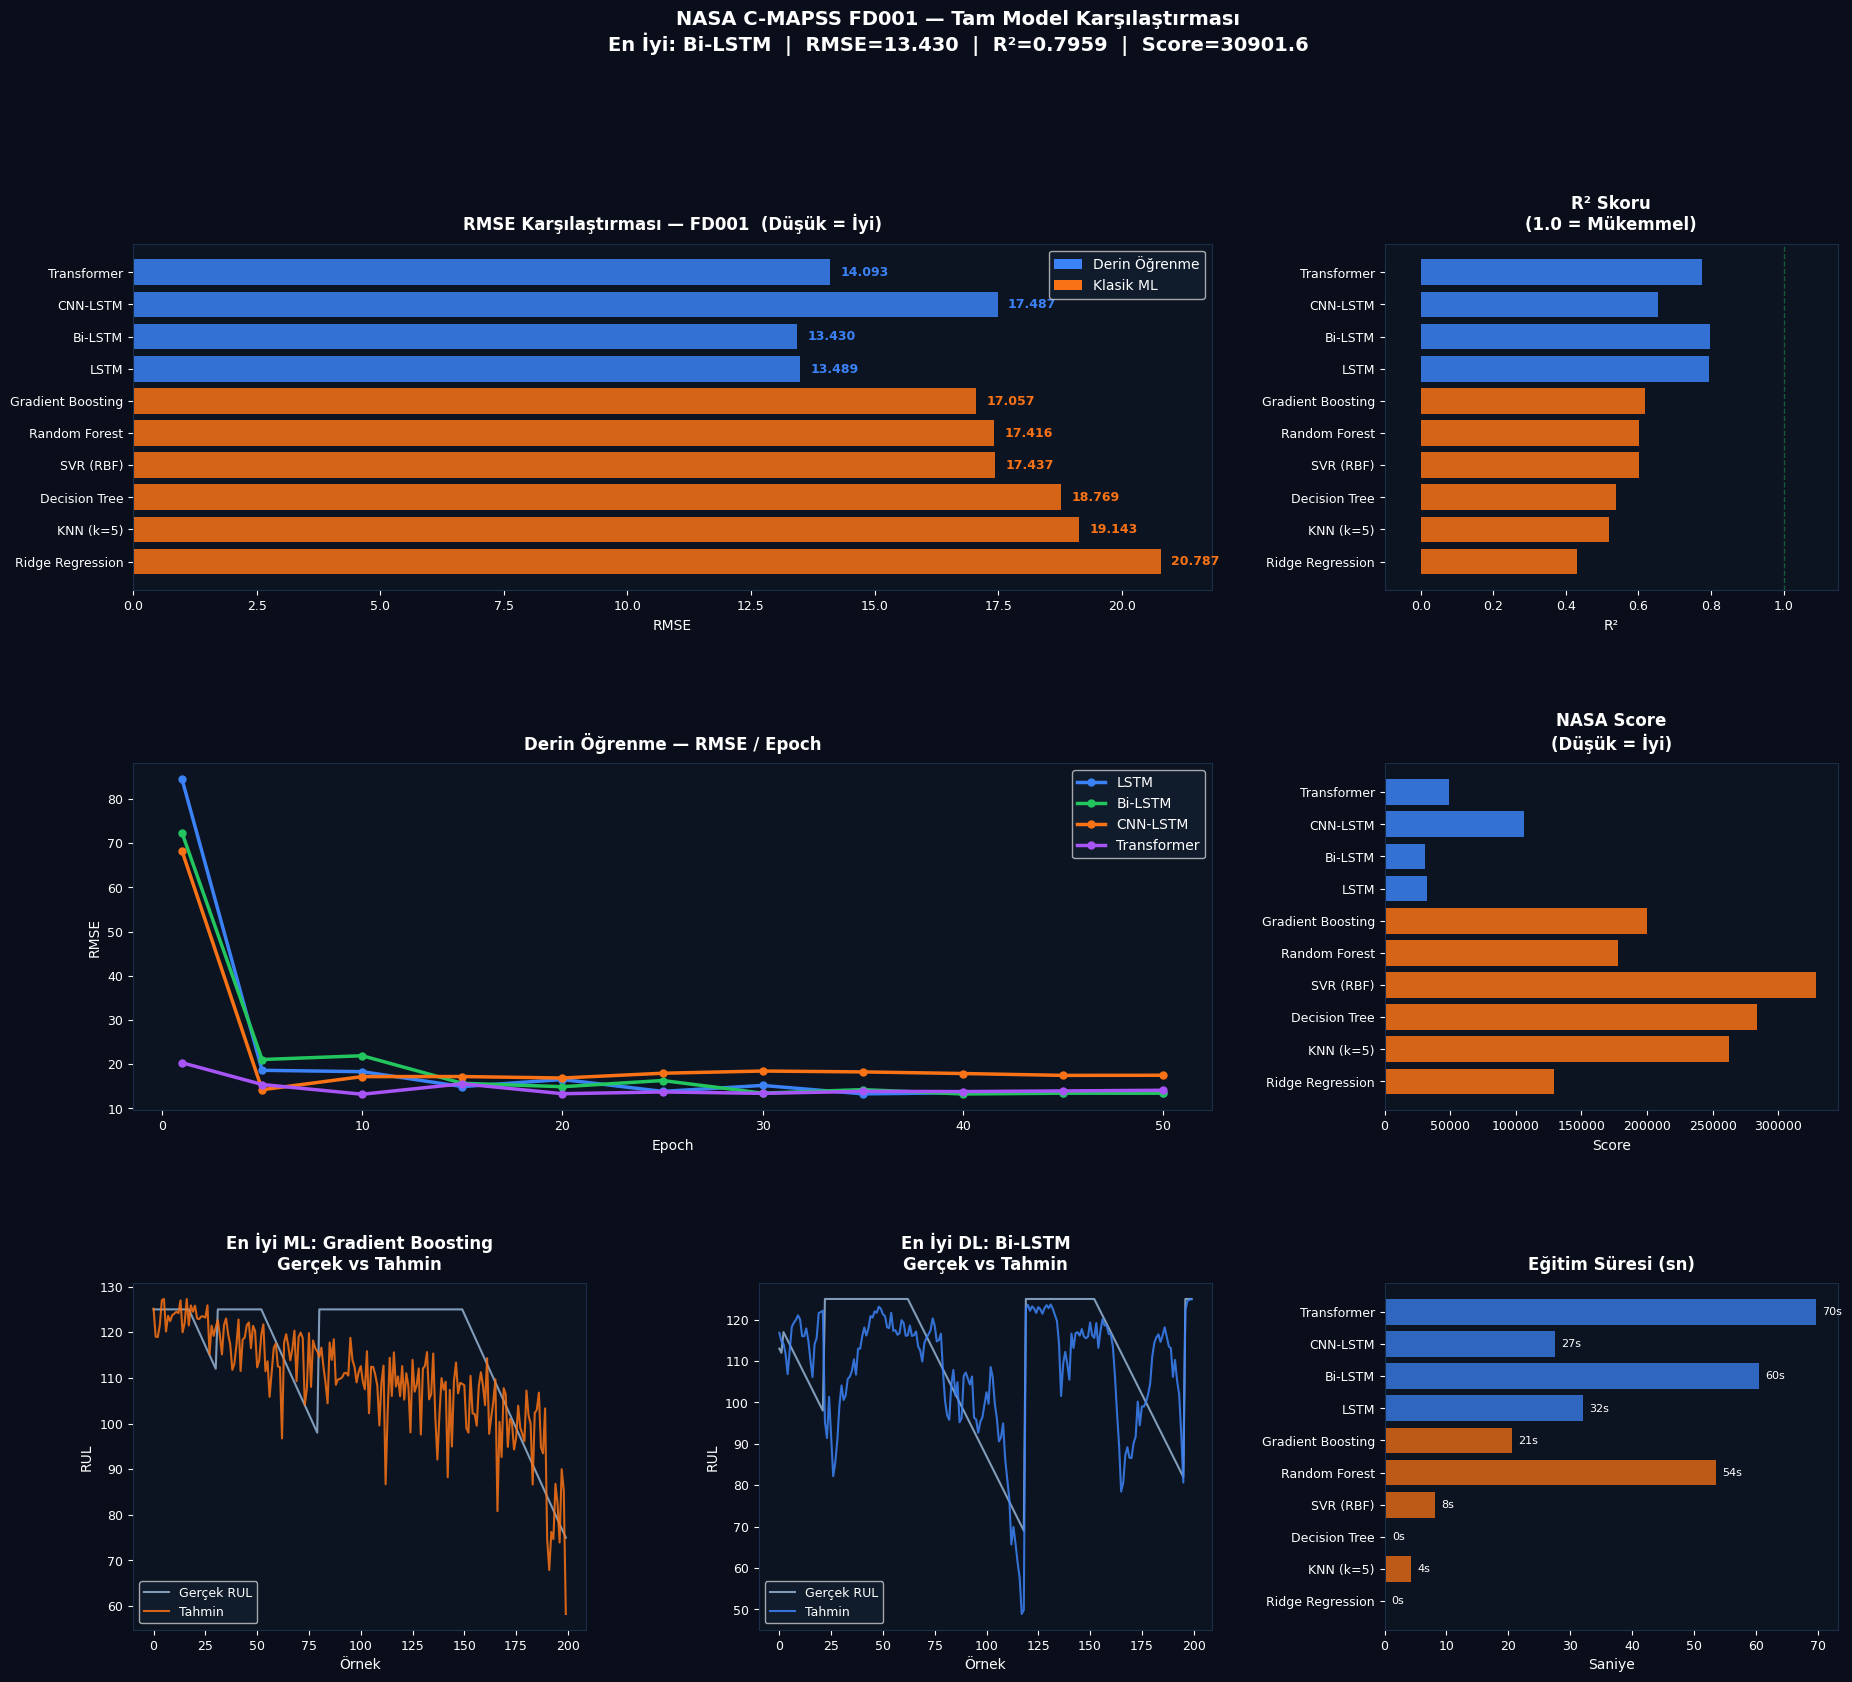

✓ Grafik kaydedildi: cmapss_FD001_comparison.png


In [14]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 11 — Görselleştirme (Rapora Hazır PNG)  ║
# ╚══════════════════════════════════════════════════╝

fig = plt.figure(figsize=(22, 18), facecolor='#0a0e1a')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

BG   = '#0d1421'
TXT  = 'white'
DIM  = '#5a7099'
BLUE = '#3b82f6'
ORG  = '#f97316'
GRN  = '#22c55e'
PRP  = '#a855f7'

names_all  = list(all_results.keys())
rmses_all  = [all_results[n]['RMSE']  for n in names_all]
r2s_all    = [all_results[n]['R2']    for n in names_all]
scores_all = [all_results[n]['Score'] for n in names_all]
times_all  = [all_results[n]['Time']  for n in names_all]
type_colors = [BLUE if all_results[n]['Type']=='DL' else ORG for n in names_all]

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TXT, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors=TXT, labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

# ── 1. RMSE Bar ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1, f'RMSE Karşılaştırması — {SUBSET}  (Düşük = İyi)')
bars = ax1.barh(names_all, rmses_all, color=type_colors, alpha=0.85, edgecolor='none')
ax1.set_xlabel('RMSE', color=TXT, fontsize=10)
for bar, val, tc in zip(bars, rmses_all, type_colors):
    ax1.text(val + max(rmses_all)*0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', color=tc, fontsize=9, fontweight='bold')
ax1.legend(handles=[mpatches.Patch(fc=BLUE, label='Derin Öğrenme'),
                     mpatches.Patch(fc=ORG,  label='Klasik ML')],
           facecolor='#111d2e', labelcolor=TXT, fontsize=10)

# ── 2. R² Bar ──────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2, 'R² Skoru\n(1.0 = Mükemmel)')
ax2.barh(names_all, r2s_all, color=type_colors, alpha=0.85, edgecolor='none')
ax2.set_xlabel('R²', color=TXT, fontsize=10)
ax2.set_xlim(-0.1, 1.15)
ax2.axvline(1.0, color=GRN, linestyle='--', alpha=0.4, linewidth=1)

# ── 3. DL Epoch Eğrisi (RMSE) ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
style_ax(ax3, 'Derin Öğrenme — RMSE / Epoch')
dl_color_map = {'LSTM': BLUE, 'Bi-LSTM': GRN, 'CNN-LSTM': ORG, 'Transformer': PRP}
for name, r in dl_results.items():
    h = r.get('history', {})
    if h.get('epoch'):
        ax3.plot(h['epoch'], h['val_rmse'],
                 label=name, color=dl_color_map.get(name, TXT),
                 linewidth=2.5, marker='o', markersize=5)
ax3.set_xlabel('Epoch', color=TXT, fontsize=10)
ax3.set_ylabel('RMSE', color=TXT, fontsize=10)
ax3.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10)

# ── 4. NASA Score ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
style_ax(ax4, 'NASA Score\n(Düşük = İyi)')
ax4.barh(names_all, scores_all, color=type_colors, alpha=0.85, edgecolor='none')
ax4.set_xlabel('Score', color=TXT, fontsize=10)

# ── 5. En iyi ML: Gerçek vs Tahmin ───────────────────────────
best_ml_name  = min(ml_results, key=lambda x: ml_results[x]['RMSE'])
best_ml_preds = ml_preds[best_ml_name][:200]
y_te_sample   = data['y_te_flat'][:200]

ax5 = fig.add_subplot(gs[2, 0])
style_ax(ax5, f'En İyi ML: {best_ml_name}\nGerçek vs Tahmin')
ax5.plot(y_te_sample,   color='#94b4d4', lw=1.5, label='Gerçek RUL', alpha=0.85)
ax5.plot(best_ml_preds, color=ORG,       lw=1.5, label='Tahmin', alpha=0.85)
ax5.set_xlabel('Örnek', color=TXT, fontsize=10)
ax5.set_ylabel('RUL', color=TXT, fontsize=10)
ax5.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

# ── 6. En iyi DL: Gerçek vs Tahmin ───────────────────────────
best_dl_name  = min(dl_results, key=lambda x: dl_results[x]['RMSE'])
best_dl_preds = dl_preds[best_dl_name][:200]
y_te_seq_samp = data['y_te_seq'][:200]

ax6 = fig.add_subplot(gs[2, 1])
style_ax(ax6, f'En İyi DL: {best_dl_name}\nGerçek vs Tahmin')
ax6.plot(y_te_seq_samp,  color='#94b4d4', lw=1.5, label='Gerçek RUL', alpha=0.85)
ax6.plot(best_dl_preds,  color=BLUE,      lw=1.5, label='Tahmin', alpha=0.85)
ax6.set_xlabel('Örnek', color=TXT, fontsize=10)
ax6.set_ylabel('RUL', color=TXT, fontsize=10)
ax6.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)

# ── 7. Eğitim Süresi ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
style_ax(ax7, 'Eğitim Süresi (sn)')
ax7.barh(names_all, times_all, color=type_colors, alpha=0.75, edgecolor='none')
ax7.set_xlabel('Saniye', color=TXT, fontsize=10)
for bar, val in zip(ax7.patches, times_all):
    ax7.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}s', va='center', color=TXT, fontsize=8)

fig.suptitle(
    f'NASA C-MAPSS {SUBSET} — Tam Model Karşılaştırması\n'
    f'En İyi: {best_name}  |  RMSE={best_rmse:.3f}  |  R²={best_r2:.4f}  |  Score={best_score:.1f}',
    color=TXT, fontsize=14, fontweight='bold', y=1.01
)

OUT_PNG = f'cmapss_{SUBSET}_comparison.png'
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print(f"✓ Grafik kaydedildi: {OUT_PNG}")


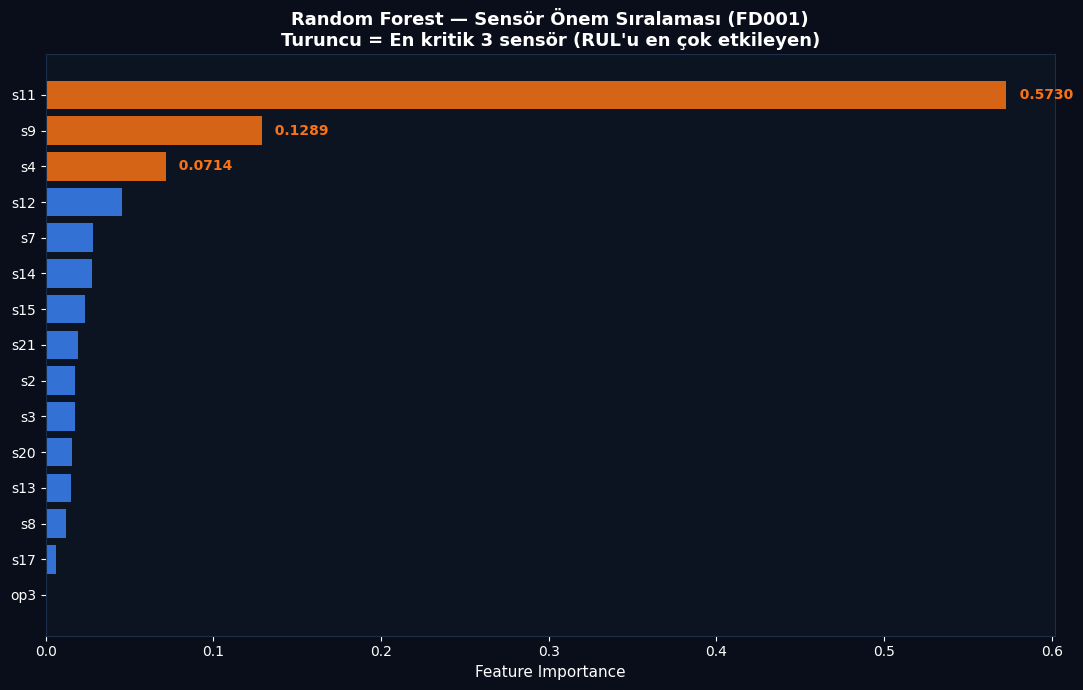


📊 En önemli 5 sensör — FD001:
   s11      → 0.57303
   s9       → 0.12894
   s4       → 0.07140
   s12      → 0.04539
   s7       → 0.02786


In [15]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 12 — Feature Importance (RF + XAI)      ║
# ╚══════════════════════════════════════════════════╝
# "Hangi sensör RUL'u en çok etkiliyor?" — XAI analizi

rf_model    = ml_models['Random Forest']
feat_cols   = data['feat_cols']
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({'Sensör': feat_cols, 'Önem': importances})
feat_df = feat_df.sort_values('Önem', ascending=True).reset_index(drop=True)

fig3, ax = plt.subplots(figsize=(11, 7), facecolor='#0a0e1a')
ax.set_facecolor('#0d1421')

# Renk: top3 turuncu, diğerleri mavi
bar_colors = [ORG if feat_df.loc[i,'Önem'] >= feat_df['Önem'].nlargest(3).min()
              else BLUE for i in range(len(feat_df))]

bars = ax.barh(feat_df['Sensör'], feat_df['Önem'],
               color=bar_colors, alpha=0.85, edgecolor='none')

ax.set_title(
    f'Random Forest — Sensör Önem Sıralaması ({SUBSET})\n'
    f'Turuncu = En kritik 3 sensör (RUL\'u en çok etkileyen)',
    color=TXT, fontsize=13, fontweight='bold'
)
ax.set_xlabel('Feature Importance', color=TXT, fontsize=11)
ax.tick_params(colors=TXT, labelsize=10)
for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

for bar, val in zip(bars, feat_df['Önem']):
    if val >= feat_df['Önem'].nlargest(3).min():
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'  {val:.4f}', va='center', color=ORG,
                fontsize=10, fontweight='bold')

plt.tight_layout()
FI_PNG = f'feature_importance_{SUBSET}.png'
plt.savefig(FI_PNG, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

print(f"\n📊 En önemli 5 sensör — {SUBSET}:")
top5 = feat_df.nlargest(5, 'Önem')[['Sensör','Önem']]
for _, row in top5.iterrows():
    print(f"   {row['Sensör']:<8} → {row['Önem']:.5f}")

In [16]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 13 — Sonuçları Drive'a Kaydet           ║
# ╚══════════════════════════════════════════════════╝

SAVE_DIR = f'/content/drive/MyDrive/cmapss_sonuclar_{SUBSET}'
os.makedirs(SAVE_DIR, exist_ok=True)

# PNG'leri kaydet
shutil.copy(OUT_PNG, SAVE_DIR)
shutil.copy(FI_PNG,  SAVE_DIR)

# Sonuçları CSV olarak kaydet
rows = []
for name, r in all_results.items():
    rows.append({
        'Model':         name,
        'Tip':           r['Type'],
        'RMSE':          round(r['RMSE'], 4),
        'MAE':           round(r['MAE'],  4),
        'R2':            round(r['R2'],   4),
        'NASA_Score':    round(r['Score'],1),
        'Egitim_sn':     round(r['Time'], 1),
    })

results_csv = pd.DataFrame(rows).sort_values('RMSE')
csv_path    = f'{SAVE_DIR}/sonuclar_{SUBSET}.csv'
results_csv.to_csv(csv_path, index=False)

print(f"\n✓ Kaydedildi: {SAVE_DIR}")
print(f"\n{results_csv.to_string(index=False)}")


✓ Kaydedildi: /content/drive/MyDrive/cmapss_sonuclar_FD001

            Model Tip    RMSE     MAE     R2  NASA_Score  Egitim_sn
          Bi-LSTM  DL 13.4304  9.7413 0.7959     30901.6       60.4
             LSTM  DL 13.4888  9.7071 0.7941     32451.5       32.0
      Transformer  DL 14.0930  8.7283 0.7752     49288.7       69.7
Gradient Boosting  ML 17.0571 12.0608 0.6175    200167.4       20.6
    Random Forest  ML 17.4158 12.6727 0.6012    177947.7       53.6
        SVR (RBF)  ML 17.4371 10.8286 0.6003    328951.1        8.2
         CNN-LSTM  DL 17.4871 12.0327 0.6539    105951.0       27.5
    Decision Tree  ML 18.7688 13.0894 0.5369    283343.1        0.3
        KNN (k=5)  ML 19.1427 13.2728 0.5182    262675.8        4.4
 Ridge Regression  ML 20.7873 16.6948 0.4319    128981.5        0.0


In [20]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 14 — [OPSİYONEL] Tüm Subsetleri Eğit   ║
# ╚══════════════════════════════════════════════════╝
# Bu hücreyi çalıştırırsan FD001-FD004 hepsini karşılaştırırsın
# Süre: ~2-3 saat

RUN_ALL_SUBSETS = True   # True yaparak aktifleştir

if RUN_ALL_SUBSETS:
    all_subset_results = {}

    for subset in ['FD001','FD002','FD003','FD004']:
        print(f"\n{'#'*60}")
        print(f"  {subset} EĞİTİMİ")
        print(f"{'#'*60}")

        d = prepare_subset(subset)
        nf = d['n_feat']

        # RF
        rf = RandomForestRegressor(200, n_jobs=-1, random_state=SEED)
        rf.fit(d['X_tr_flat'], d['y_tr_flat'])
        rf_preds = rf.predict(d['X_te_flat'])
        rf_m = metrics(d['y_te_flat'], rf_preds)

        # Bi-LSTM (en iyi DL genellikle)
        bilstm = BiLSTMModel(nf)
        bilstm_m, _ = train_dl_model(bilstm, d, epochs=50, batch=128, name=f'BiLSTM-{subset}')

        all_subset_results[subset] = {
            'Random Forest': rf_m,
            'Bi-LSTM':       bilstm_m,
        }

    # Özet tablo
    print(f"\n{'='*65}")
    print(f"  TÜM SUBSETLER ÖZET")
    print(f"{'='*65}")
    for ss, res in all_subset_results.items():
        print(f"\n  {ss}:")
        for mn, mr in res.items():
            print(f"    {mn:<20} RMSE={mr['RMSE']:.3f}  R²={mr['R2']:.4f}")
_execute_


############################################################
  FD001 EĞİTİMİ
############################################################

[FD001] Hazırlanıyor... ✓  Seq: (17731, 30, 15) / Flat: (20631, 15)
  [BiLSTM-FD001] Ep   1/50  Loss=3704.9668  RMSE=39.612  R²=-0.7757
  [BiLSTM-FD001] Ep   5/50  Loss=411.3432  RMSE=19.794  R²=0.5566
  [BiLSTM-FD001] Ep  10/50  Loss=314.6568  RMSE=16.748  R²=0.6826
  [BiLSTM-FD001] Ep  15/50  Loss=220.7887  RMSE=14.151  R²=0.7734
  [BiLSTM-FD001] Ep  20/50  Loss=196.4966  RMSE=13.390  R²=0.7971
  [BiLSTM-FD001] Ep  25/50  Loss=186.6095  RMSE=13.636  R²=0.7896
  [BiLSTM-FD001] Ep  30/50  Loss=179.1504  RMSE=13.360  R²=0.7980
  [BiLSTM-FD001] Ep  35/50  Loss=172.0952  RMSE=14.038  R²=0.7770
  [BiLSTM-FD001] Ep  40/50  Loss=165.5036  RMSE=13.290  R²=0.8001
  [BiLSTM-FD001] Ep  45/50  Loss=161.4029  RMSE=14.043  R²=0.7768
  [BiLSTM-FD001] Ep  50/50  Loss=161.1465  RMSE=13.830  R²=0.7835

############################################################
  